In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# Visual theme matching the deployed application (indigo = Diabetic, cyan = Non-Diabetic)
sns.set_theme(style='whitegrid', rc={'axes.edgecolor': '#e2e8f0', 'grid.color': '#eef2f7'})
plt.rcParams.update({'font.size': 11, 'axes.titlesize': 13, 'axes.titleweight': 'bold'})

BRAND_DIABETIC = '#6366f1'      # indigo
BRAND_NON_DIABETIC = '#06b6d4'  # cyan
BRAND_NEUTRAL = '#818cf8'       # soft indigo, for single-series charts
OUTCOME_PALETTE = {0: BRAND_NON_DIABETIC, 1: BRAND_DIABETIC}
BRAND_CMAP = LinearSegmentedColormap.from_list('brand_diverging', [BRAND_NON_DIABETIC, '#f8fafc', BRAND_DIABETIC])

# Load the dataset
df = pd.read_csv("diabetes_dataset.csv")

# Display the first few rows and the data types
display(df.head())
display(df.info())


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


None

# 1. Correlation heatmap
- What it represents: A color-coded matrix showing the Pearson correlation coefficients between every numerical feature in the dataset. The values range from -1 (perfect negative correlation) to +1 (perfect positive correlation), with 0 indicating no linear relationship.
- Why it's useful: It quickly highlights which features are strongly related to each other and which features are most predictive of the target variable (Outcome). For instance, dark red squares indicate strong positive correlations (like Age and Pregnancies), helping you identify potential multicollinearity or strong predictors.

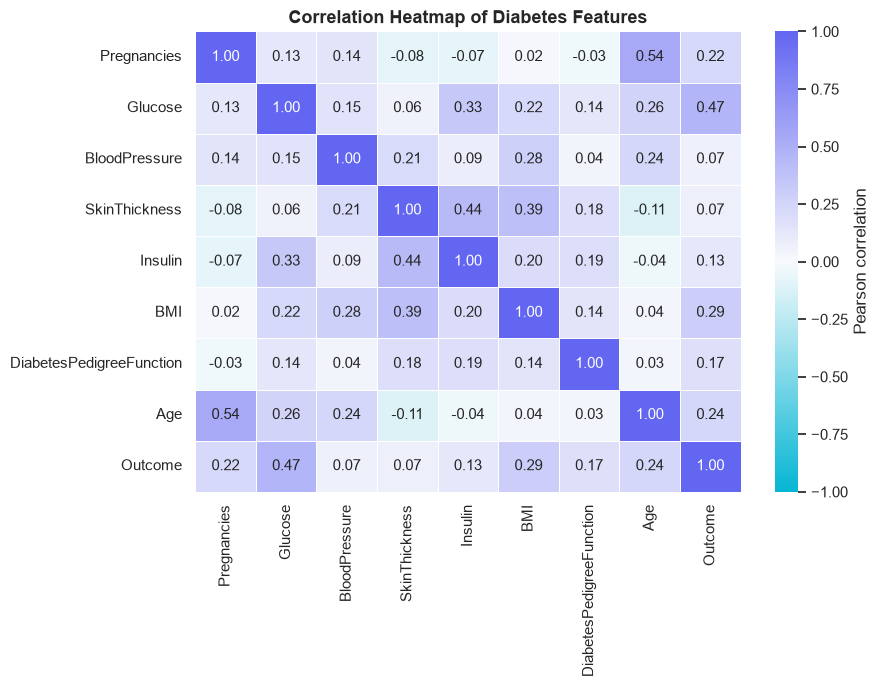

In [2]:
# 1. Correlation Heatmap
plt.figure(figsize=(9, 7))
sns.heatmap(df.corr(), annot=True, cmap=BRAND_CMAP, fmt=".2f", vmin=-1, vmax=1,
            linewidths=0.5, linecolor='white', cbar_kws={'label': 'Pearson correlation'})
plt.title('Correlation Heatmap of Diabetes Features')
plt.tight_layout()
plt.show()


# 2. Pairplot of Selected Features
- What it represents: A grid of scatterplots for every combination of the selected features (Glucose, BMI, Age, Insulin), with the data points colored by the Outcome (diabetic vs. non-diabetic). The diagonal shows the kernel density estimation (the smoothed shape of the distribution) for each feature.
- Why it's useful: It allows you to visually inspect multiple pairwise relationships at once. You can see if there are clear clusters or boundaries between the two outcome classes across two dimensions simultaneously (e.g., if high BMI and high Glucose together perfectly separate the classes).

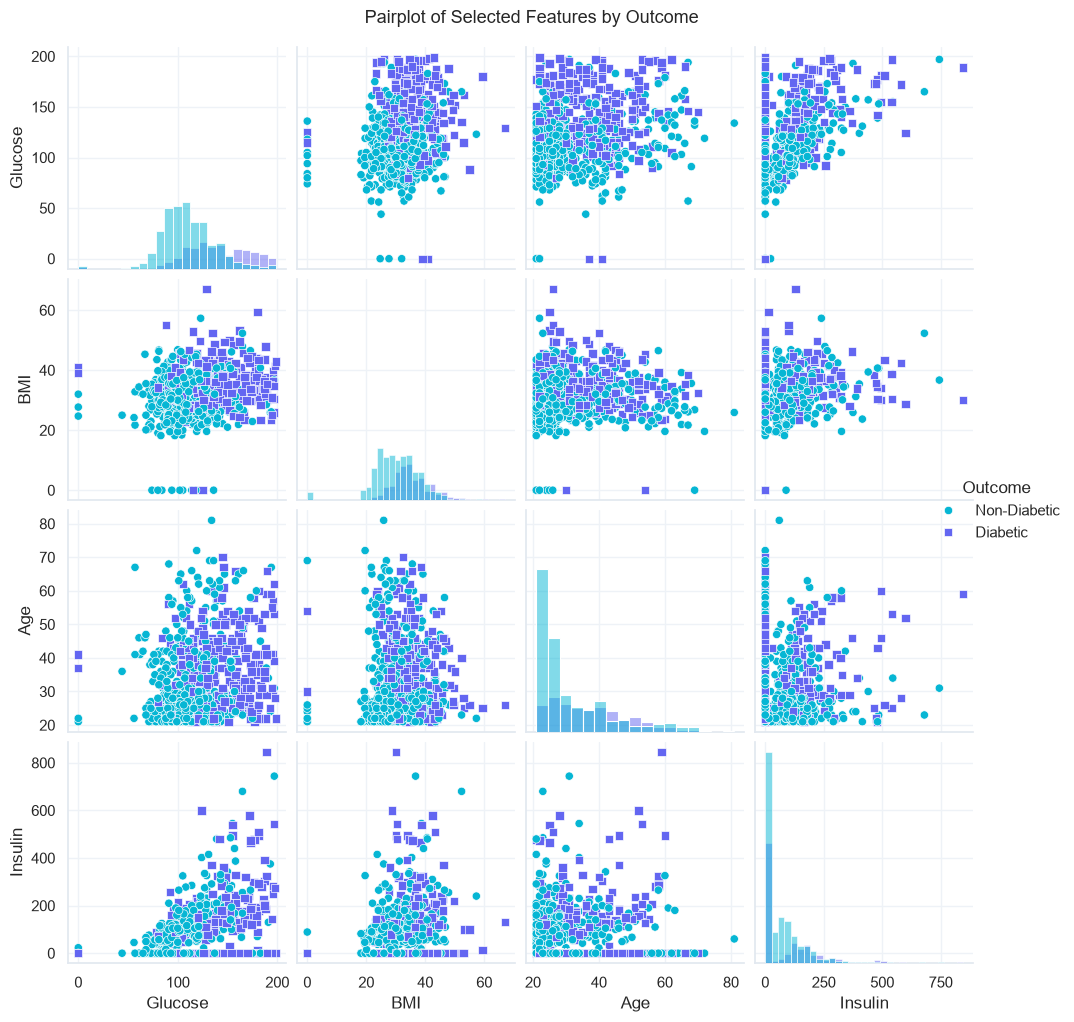

In [3]:
# 2. Pairplot of important features
features_to_plot = ['Glucose', 'BMI', 'Age', 'Insulin', 'Outcome']

g = sns.pairplot(df[features_to_plot], hue='Outcome', palette=OUTCOME_PALETTE, diag_kind='hist', markers=['o', 's'])
g._legend.set_title('Outcome')
for t, label in zip(g._legend.texts, ['Non-Diabetic', 'Diabetic']):
    t.set_text(label)
plt.suptitle('Pairplot of Selected Features by Outcome', y=1.02)
plt.show()


# 3. Boxplots (Glucose, BMI, Age vs Outcome)
- What it represents: A visual summary of the data distribution for specific features, split by the outcome class. The "box" represents the middle 50% of the data (Interquartile Range), the horizontal line inside is the median, the "whiskers" show the typical range, and the individual diamond points represent outliers.
- Why it's useful: Boxplots are the best way to compare the central tendency (averages) and spread of a feature between groups. They clearly show that the median glucose level and median BMI are noticeably higher in the diabetic group.

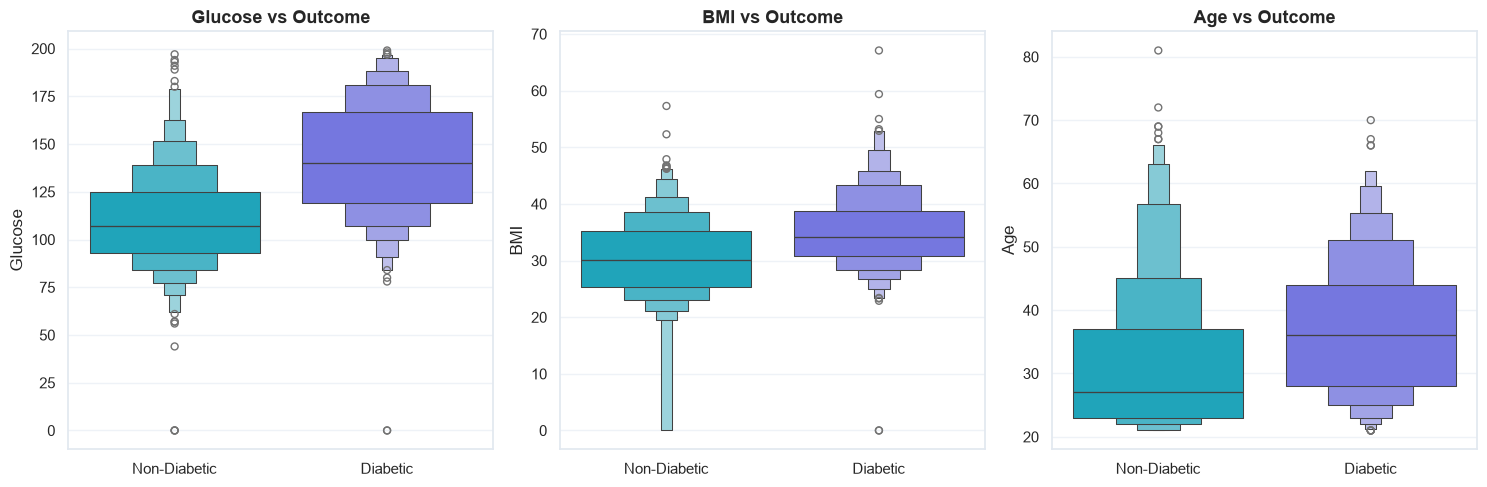

In [4]:
# 3. Boxenplots for distributions by outcome
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, feature in zip(axes, ['Glucose', 'BMI', 'Age']):
    sns.boxenplot(x='Outcome', y=feature, data=df, hue='Outcome', palette=OUTCOME_PALETTE, legend=False, ax=ax)
    ax.set_title(f'{feature} vs Outcome')
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Non-Diabetic', 'Diabetic'])
    ax.set_xlabel('')

plt.tight_layout()
plt.show()


# 4. Target Variable Distribution (Countplot)
- What it represents: A simple bar chart showing the total count of patients in each category of the Outcome variable (0 for non-diabetic, 1 for diabetic).
- Why it's useful: It tells you if your dataset is "balanced" or "imbalanced." In this dataset, there are roughly twice as many non-diabetic patients as diabetic patients. This is crucial context for training machine learning models, as severe imbalance can bias the model.

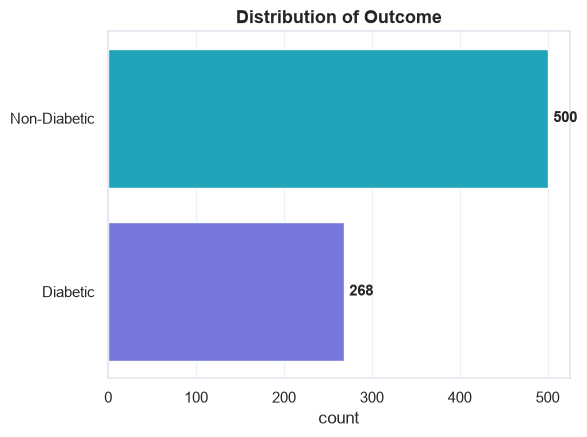

In [5]:
# 4. Target Variable Distribution
plt.figure(figsize=(6, 4.5))
ax = sns.countplot(y='Outcome', data=df, hue='Outcome', palette=OUTCOME_PALETTE, legend=False)
ax.set_yticks([0, 1])
ax.set_yticklabels(['Non-Diabetic', 'Diabetic'])
ax.set_ylabel('')
for p in ax.patches:
    ax.annotate(f'{int(p.get_width())}', (p.get_width(), p.get_y() + p.get_height() / 2),
                ha='left', va='center', fontweight='bold', xytext=(4, 0), textcoords='offset points')
plt.title('Distribution of Outcome')
plt.tight_layout()
plt.show()


# 5. Histograms of All Features
- What it represents: A grid of bar charts where the x-axis represents the value range of a feature, and the y-axis represents the number of times (frequency) those values appear in the dataset.
- Why it's useful: Histograms show the underlying shape of the data. You can easily spot skewness (e.g., Age and Pregnancies are heavily skewed to the right) and detect anomalies (e.g., the massive spike at zero for Insulin and SkinThickness, which indicates missing medical measurements rather than actual zero values).

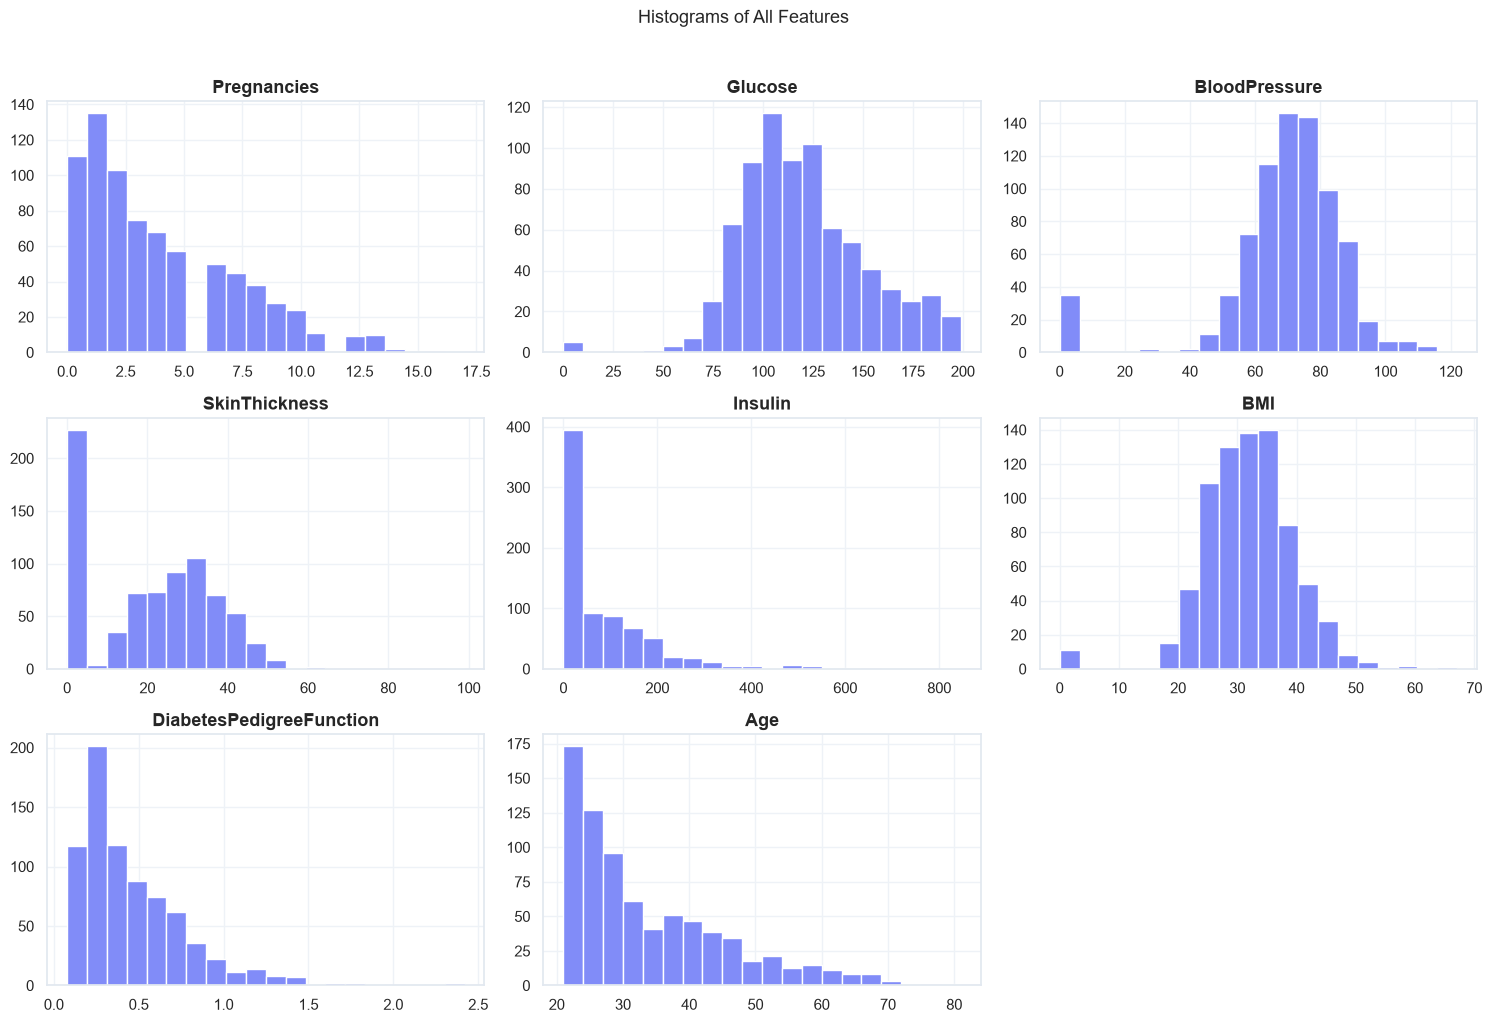

In [6]:
# 5. Histograms for all features (Split into a grid)
df.drop('Outcome', axis=1).hist(bins=20, figsize=(15, 10), color=BRAND_NEUTRAL, edgecolor='white')
plt.suptitle('Histograms of All Features', y=1.02)
plt.tight_layout()
plt.show()


# 6. Violin Plots (Parts 1 & 2)
- What it represents: A hybrid between a boxplot and a kernel density plot. It shows the same statistical summary as a boxplot (represented by the dashed lines inside), but the outer shape represents the probability density of the data at different values (wider sections mean a higher concentration of data points).
- Why it's useful: Unlike boxplots, violin plots show you if the data is multimodal (having more than one peak). They give a much richer, smoother picture of how the data is distributed across the two outcome classes.

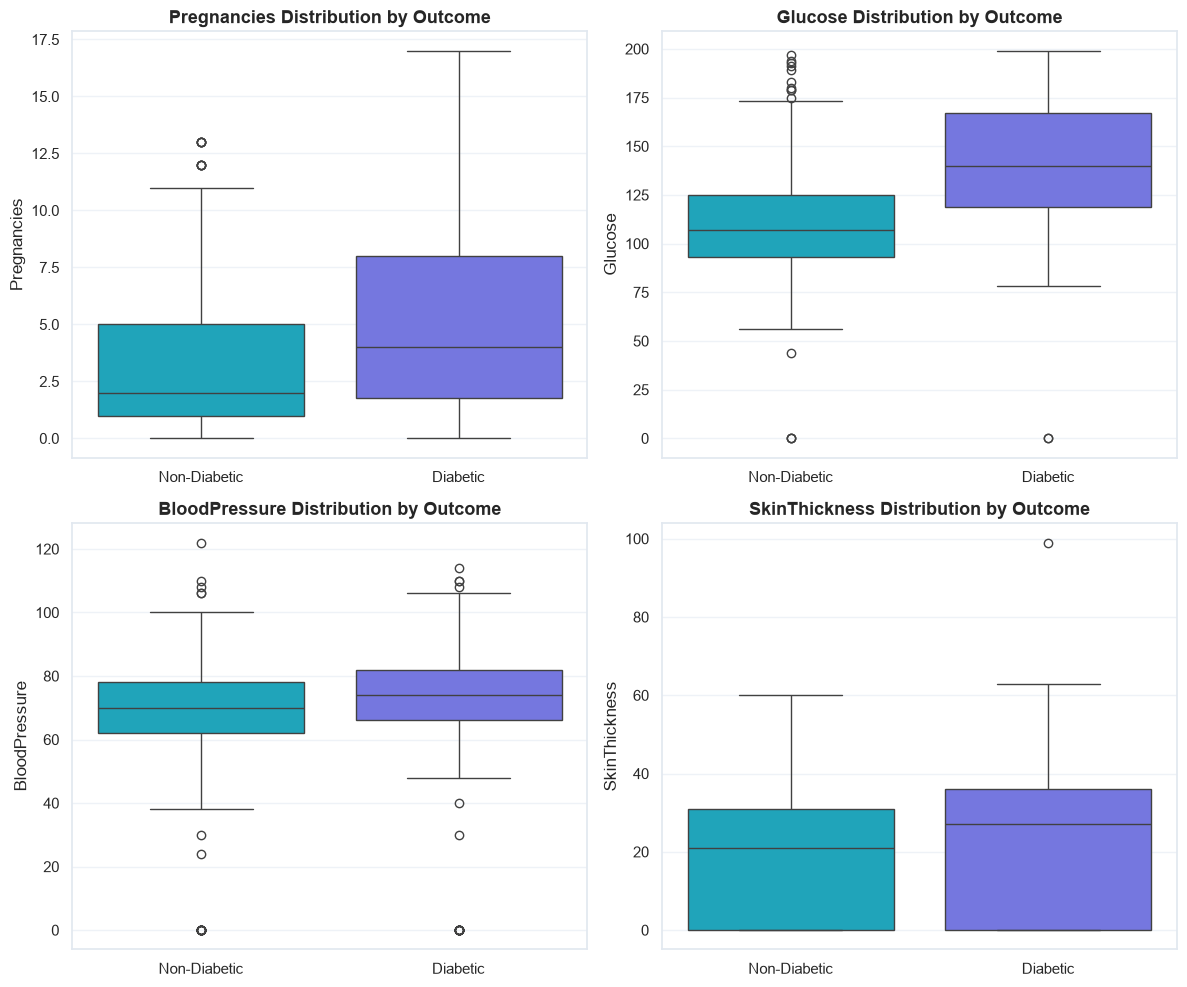

In [7]:
# 6. Box plots - Part 1
features_part1 = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness']
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, feature in enumerate(features_part1):
    sns.boxplot(x='Outcome', y=feature, data=df, hue='Outcome', palette=OUTCOME_PALETTE, legend=False, ax=axes[i])
    axes[i].set_title(f'{feature} Distribution by Outcome')
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(['Non-Diabetic', 'Diabetic'])
    axes[i].set_xlabel('')

plt.tight_layout()
plt.show()


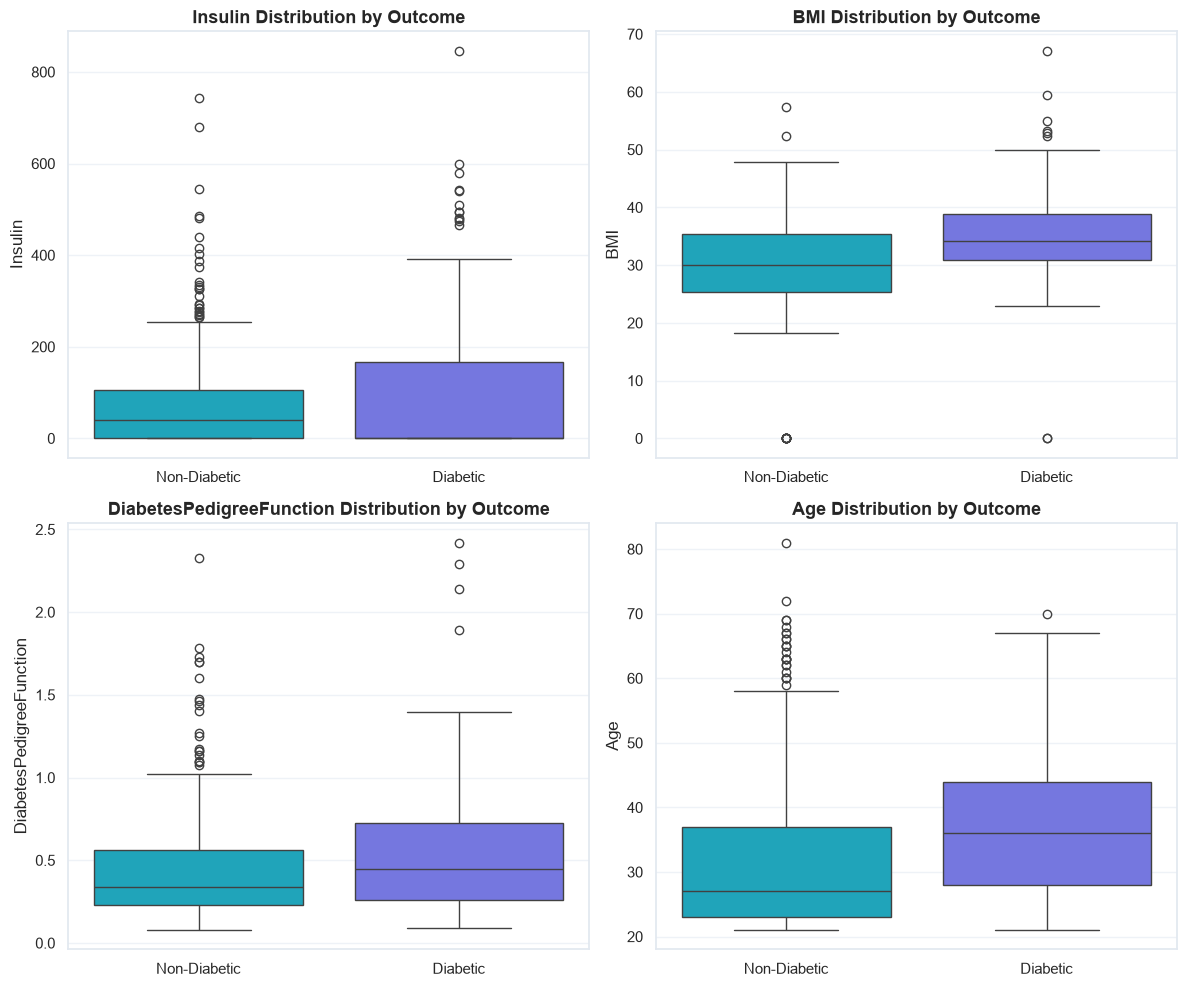

In [8]:
# 6. Box plots - Part 2
features_part2 = ['Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, feature in enumerate(features_part2):
    sns.boxplot(x='Outcome', y=feature, data=df, hue='Outcome', palette=OUTCOME_PALETTE, legend=False, ax=axes[i])
    axes[i].set_title(f'{feature} Distribution by Outcome')
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(['Non-Diabetic', 'Diabetic'])
    axes[i].set_xlabel('')

plt.tight_layout()
plt.show()


# 7. Joint Distribution of Glucose and BMI
- What it represents: The central area is a scatter plot mapping Glucose against BMI, with data points color-coded by the Outcome (diabetic vs. non-diabetic). The graphs on the top and right margins are Kernel Density Estimate (KDE) plots, which show the overlapping distribution curves of these features for both classes.
- Why it's useful: It provides a highly concentrated view of the dataset's two strongest predictors. You can simultaneously observe the bivariate relationship (e.g., higher concentrations of diabetic patients in the upper-right quadrant where both BMI and Glucose are high) while also seeing the exact points where the distributions of the two groups diverge on the margins.

C:\Users\Admin\AppData\Local\Temp\ipykernel_31764\1596739412.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  g.ax_joint.legend(title='Outcome')


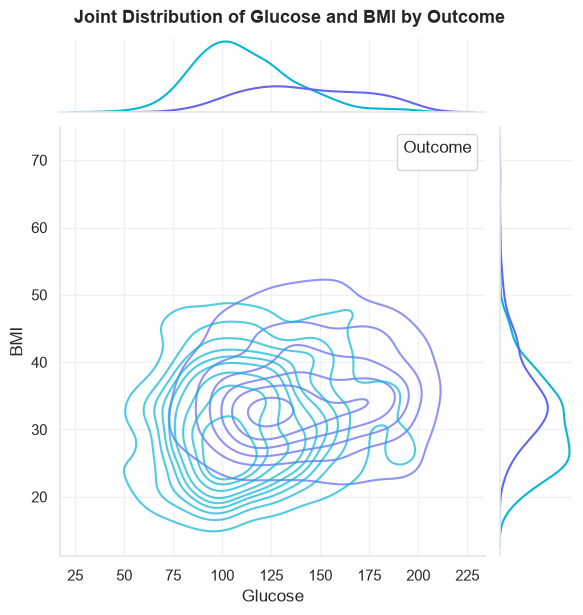

In [9]:
# 7. Joint Distribution of Glucose and BMI (Replaces the previous regression plot)
import seaborn as sns
import matplotlib.pyplot as plt

# Filter out 0 values for BMI and Glucose to ensure the plot represents realistic medical data
df_clean = df[(df['BMI'] > 0) & (df['Glucose'] > 0)].copy()
df_clean['Outcome_Label'] = df_clean['Outcome'].map({0: 'Non-Diabetic', 1: 'Diabetic'})

# Generate the Jointplot (KDE style)
g = sns.jointplot(x='Glucose', y='BMI', data=df_clean, hue='Outcome_Label', kind='kde',
                   palette={'Non-Diabetic': BRAND_NON_DIABETIC, 'Diabetic': BRAND_DIABETIC}, alpha=0.7)
g.ax_joint.legend(title='Outcome')
g.fig.suptitle('Joint Distribution of Glucose and BMI by Outcome', y=1.02, fontweight='bold')

plt.show()
